In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

## Классная работа

In [48]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(5, 1)
    
    def forward(self, x):
        x = self.l1(x).sigmoid()
        return x

model = MyModel()

In [49]:
transforms = tfs.Compose([tfs.ToImage(), tfs.Grayscale(), tfs.ToDtype(torch.float32, scale=True)])
optimizer = optim.Adam(params=model.parameters(), lr=0.01)

### Сохранение отдельно чего-либо

In [9]:
st = model.state_dict()
torch.save(st, "weights/initial_model_weights.tar")

### Загрузка отдельно чего-либо

In [46]:
st_load = torch.load("weights/initial_model_weights.tar", weights_only=True, map_location='cpu') # map_location - явное указание, куда разместить полученные данные
model.load_state_dict(st_load)
model

MyModel(
  (l1): Linear(in_features=5, out_features=1, bias=True)
)

### Загрузка сразу нескольких параметров

In [38]:
st_all = {
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "transforms": transforms.state_dict()
}

torch.save(st_all, "weights/all_thing.tar")

In [39]:
st_all_load = torch.load("weights/all_thing.tar", weights_only=True)

In [43]:
model.load_state_dict(st_all_load['model'])
optimizer.load_state_dict(st_all_load['optimizer'])
transforms.load_state_dict(st_all_load['transforms'])

<All keys matched successfully>

## Домашняя работа

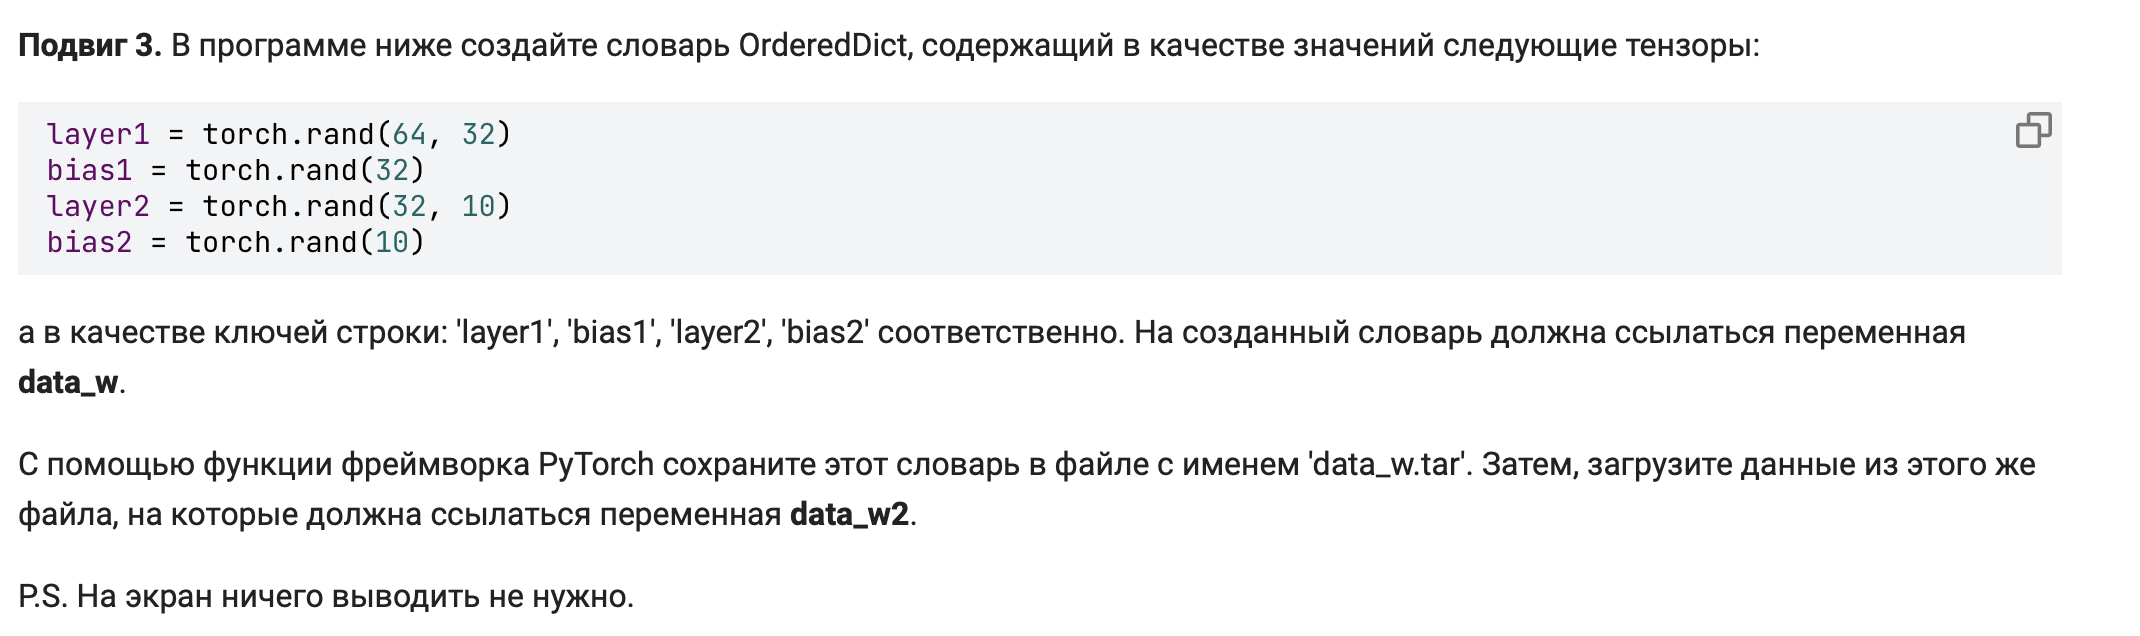

In [ ]:
# эти тензоры в программе не менять
layer1 = torch.rand(64, 32)
bias1 = torch.rand(32)
layer2 = torch.rand(32, 10)
bias2 = torch.rand(10)

# здесь продолжайте программу
data_w = {
    'layer1': layer1,
    'bias1': bias1,
    'layer2': layer2,
    'bias2': bias2
}

torch.save(data_w, "data_w.tar")
data_w2 = torch.load("data_w.tar", weights_only=True)

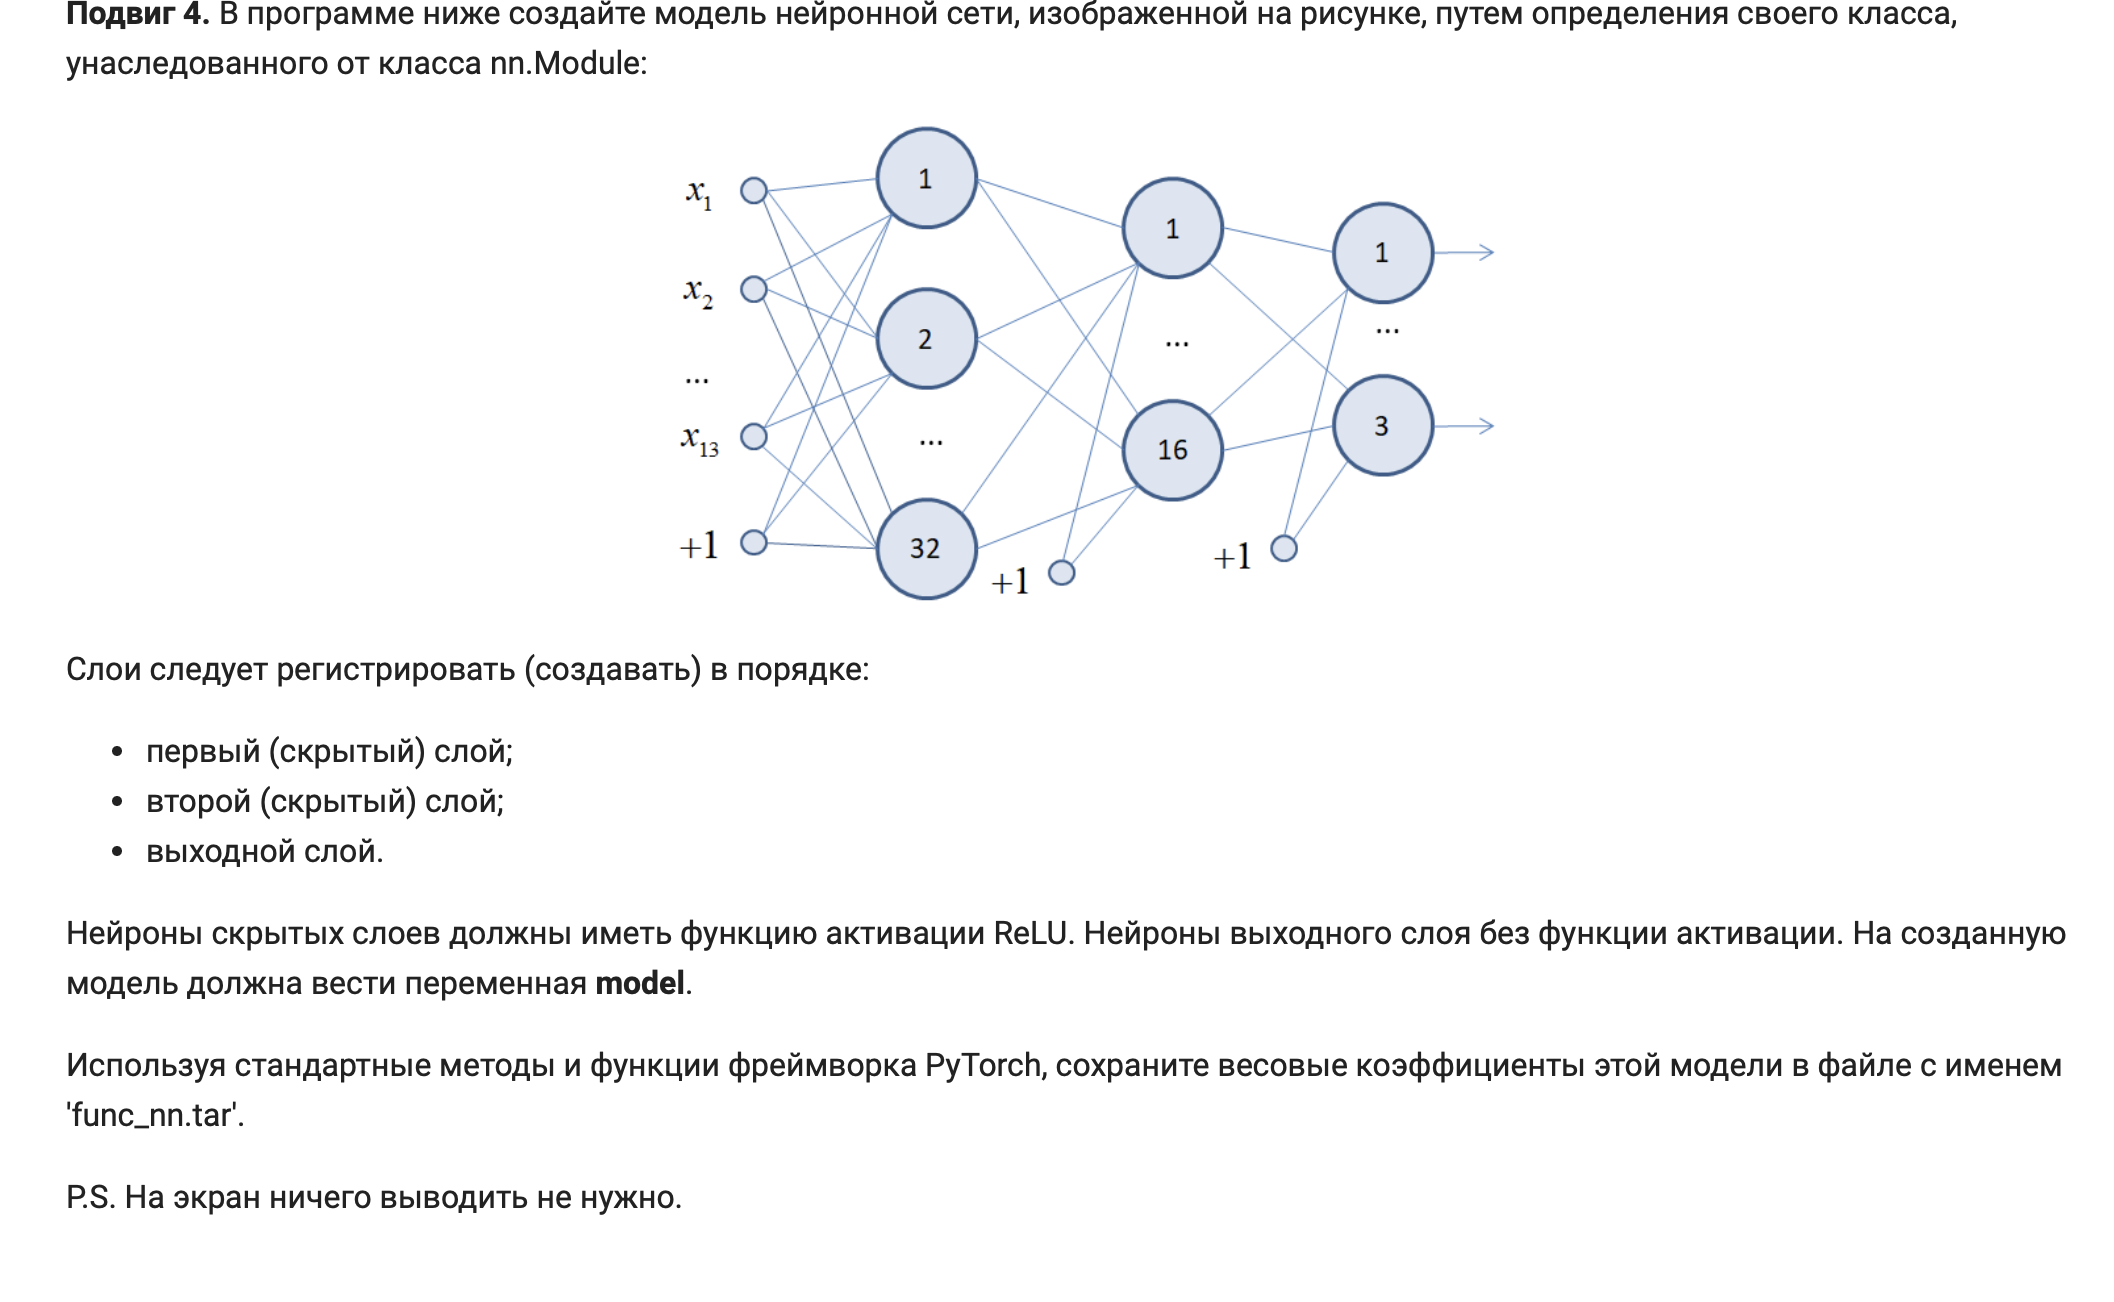

In [ ]:
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid1)
        self.l2 = nn.Linear(hid1, hid2)
        self.l3 = nn.Linear(hid2, out)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.l2(x).relu()
        x = self.l3(x)

        return x
    
model = Model(13, 32, 16, 3)
torch.save(model.state_dict(), "func_nn.tar")

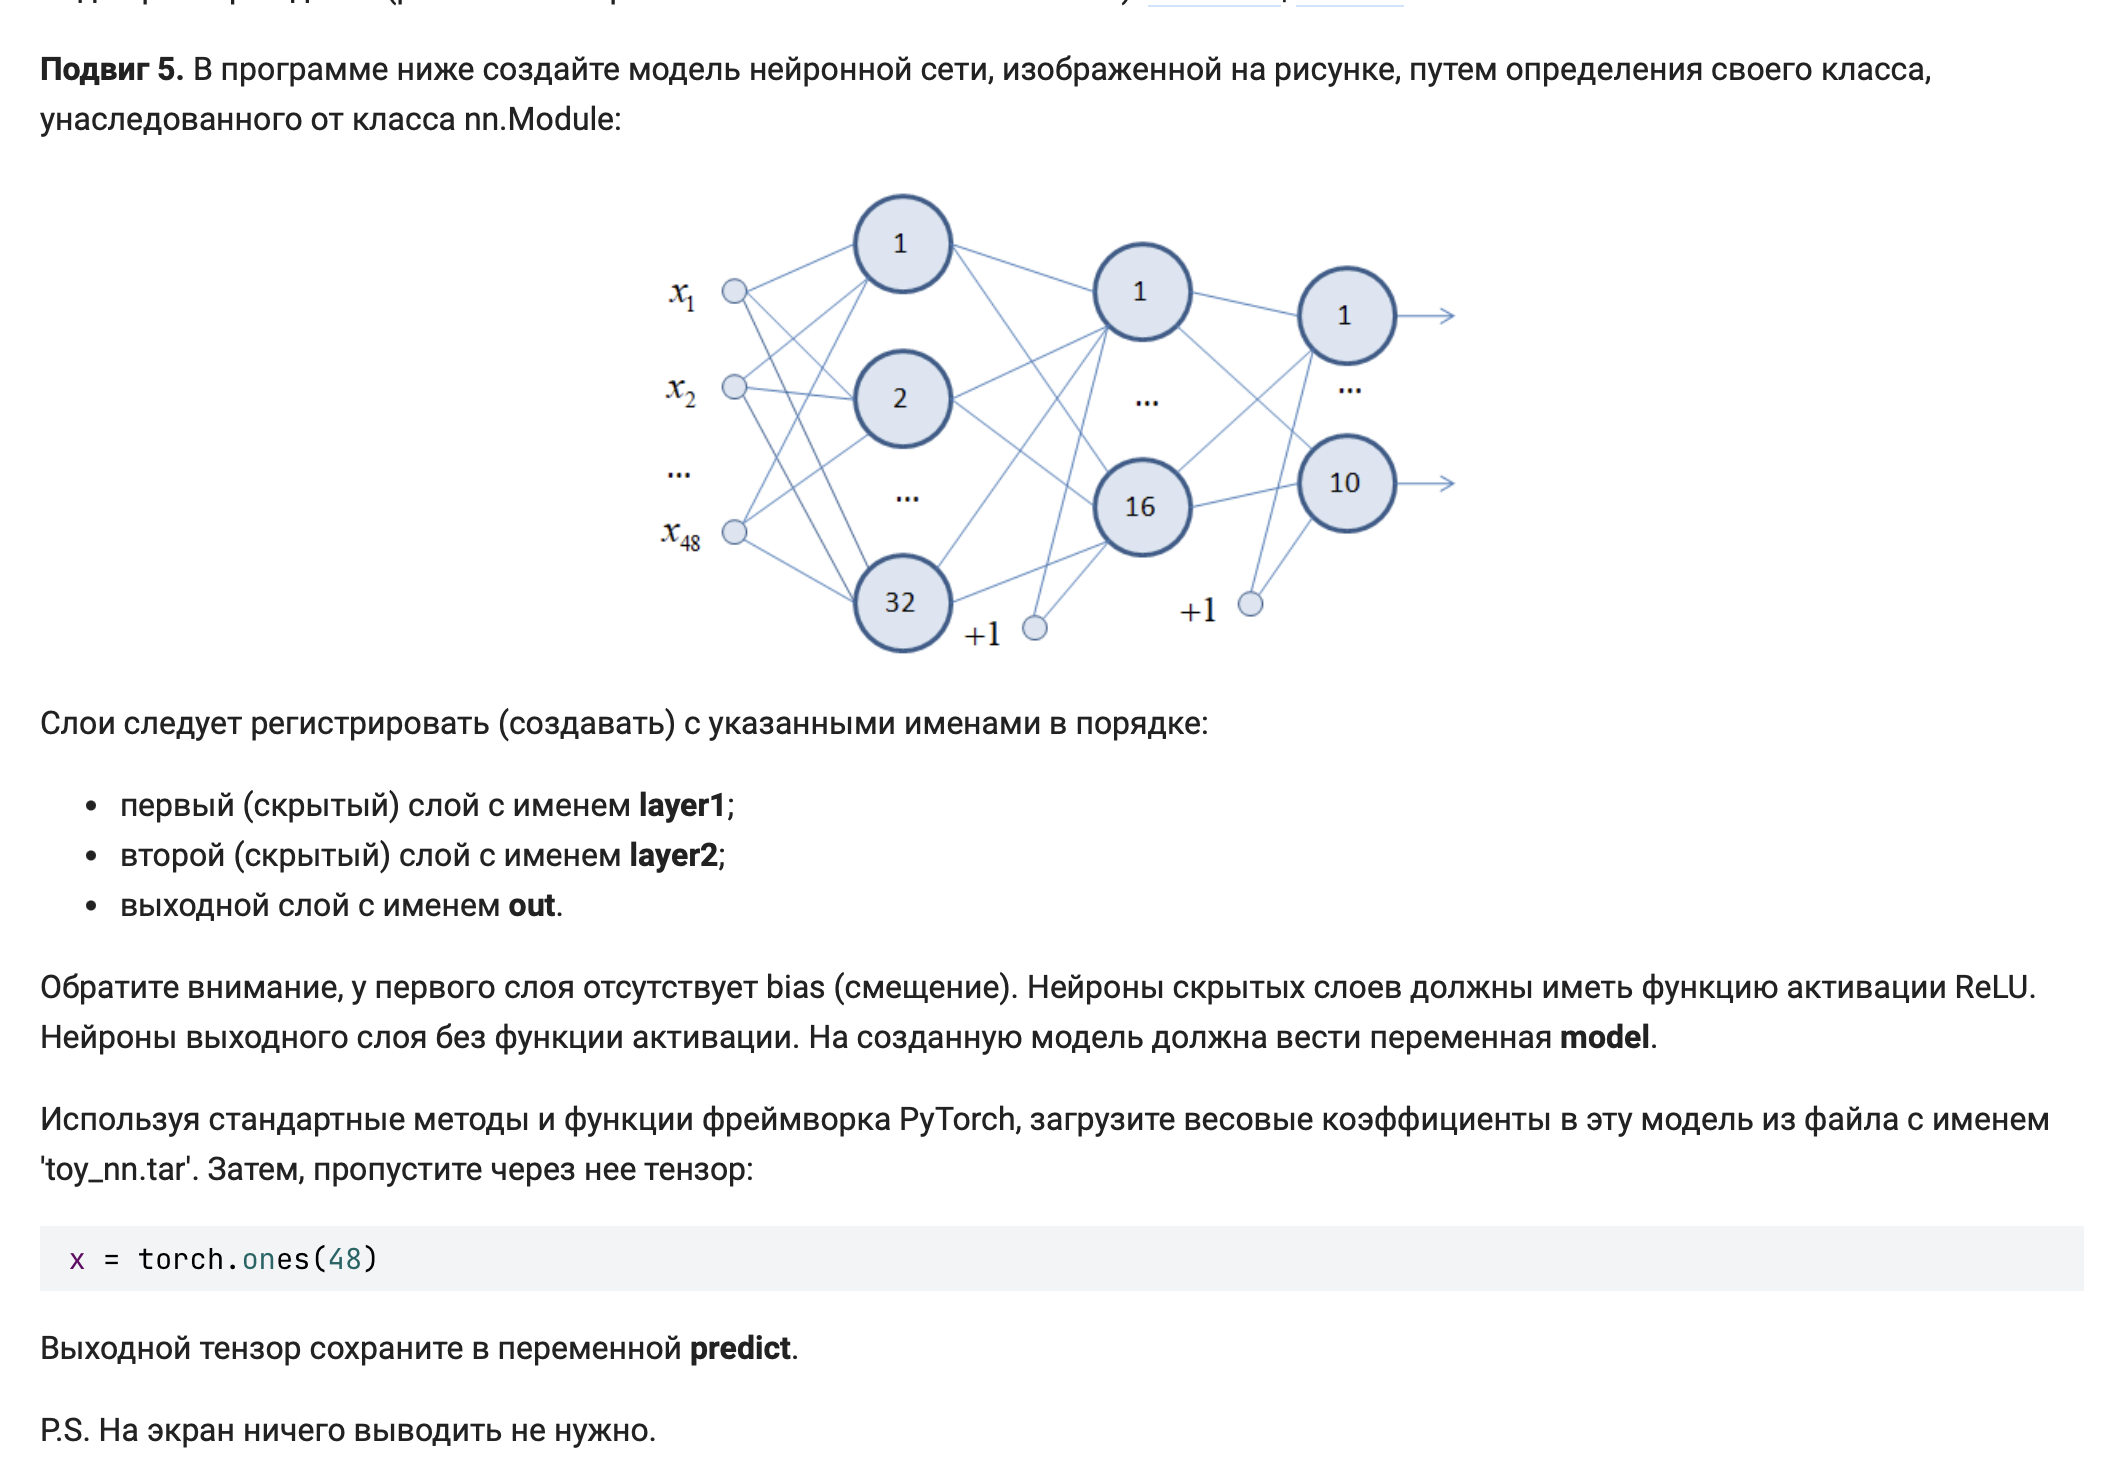

In [ ]:
# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out):
        super().__init__()
        self.layer1 = nn.Linear(inp, hid1, bias=False)
        self.layer2 = nn.Linear(hid1, hid2)
        self.out = nn.Linear(hid2, out)

    def forward(self, x):
        x = self.layer1(x).relu()
        x = self.layer2(x).relu()
        x = self.out(x)

        return x

x = torch.ones(48) # тензор в программе не менять

# здесь продолжайте программу
model = Model(48, 32, 16, 10)
st = torch.load("toy_nn.tar", weights_only=True)
model.load_state_dict(st)
predict = model(x)

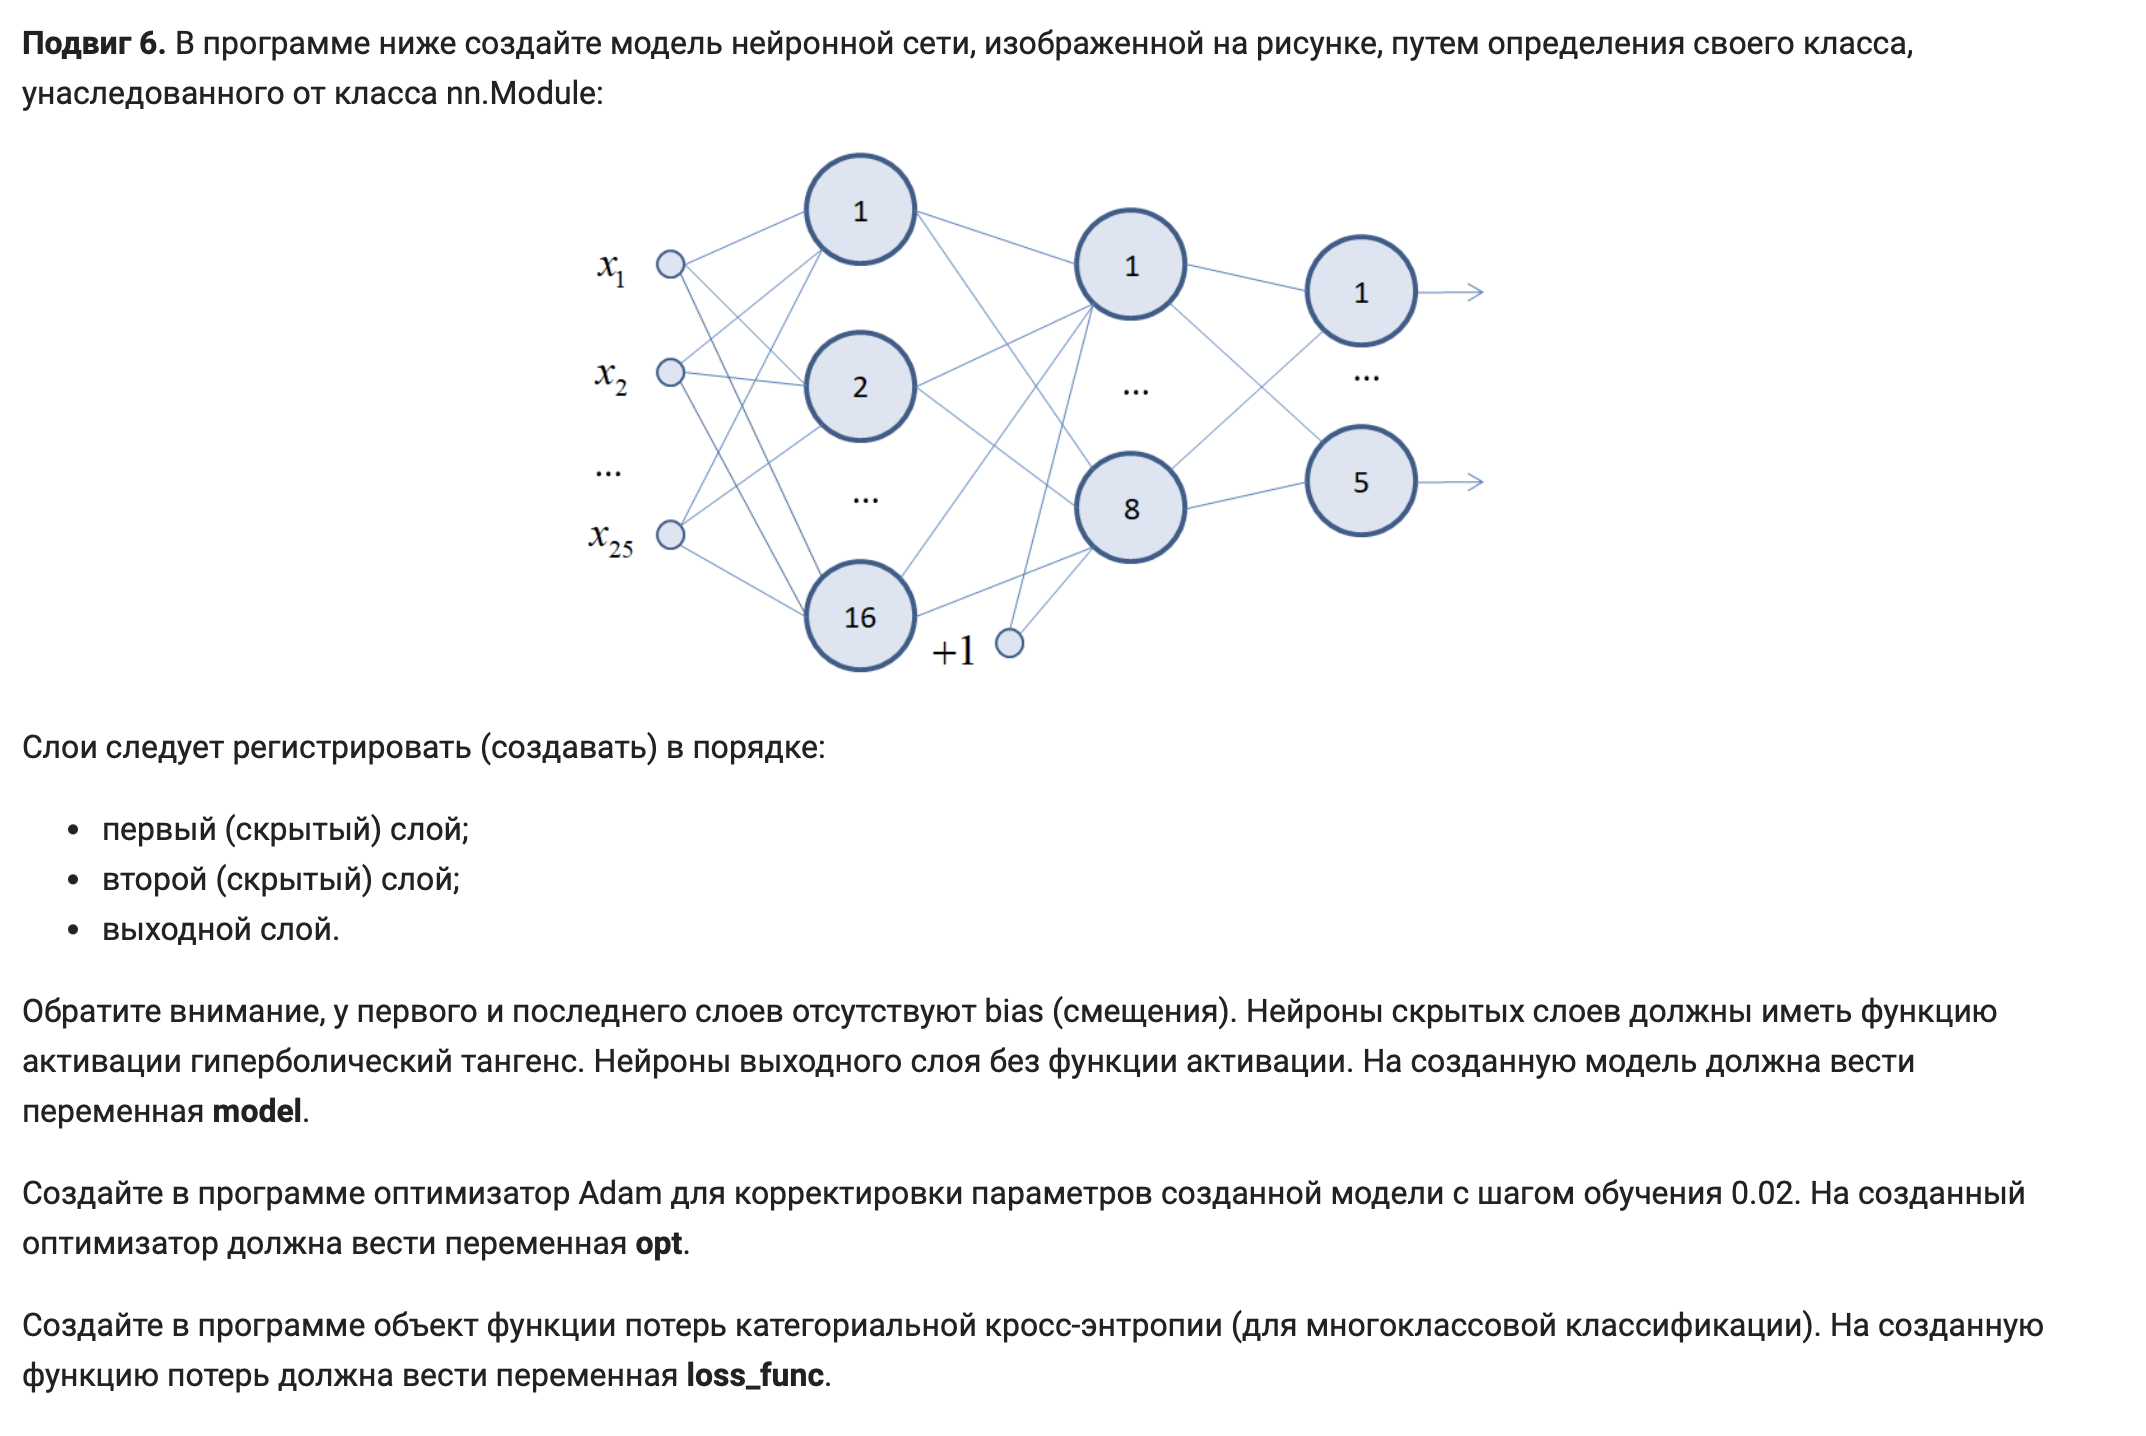
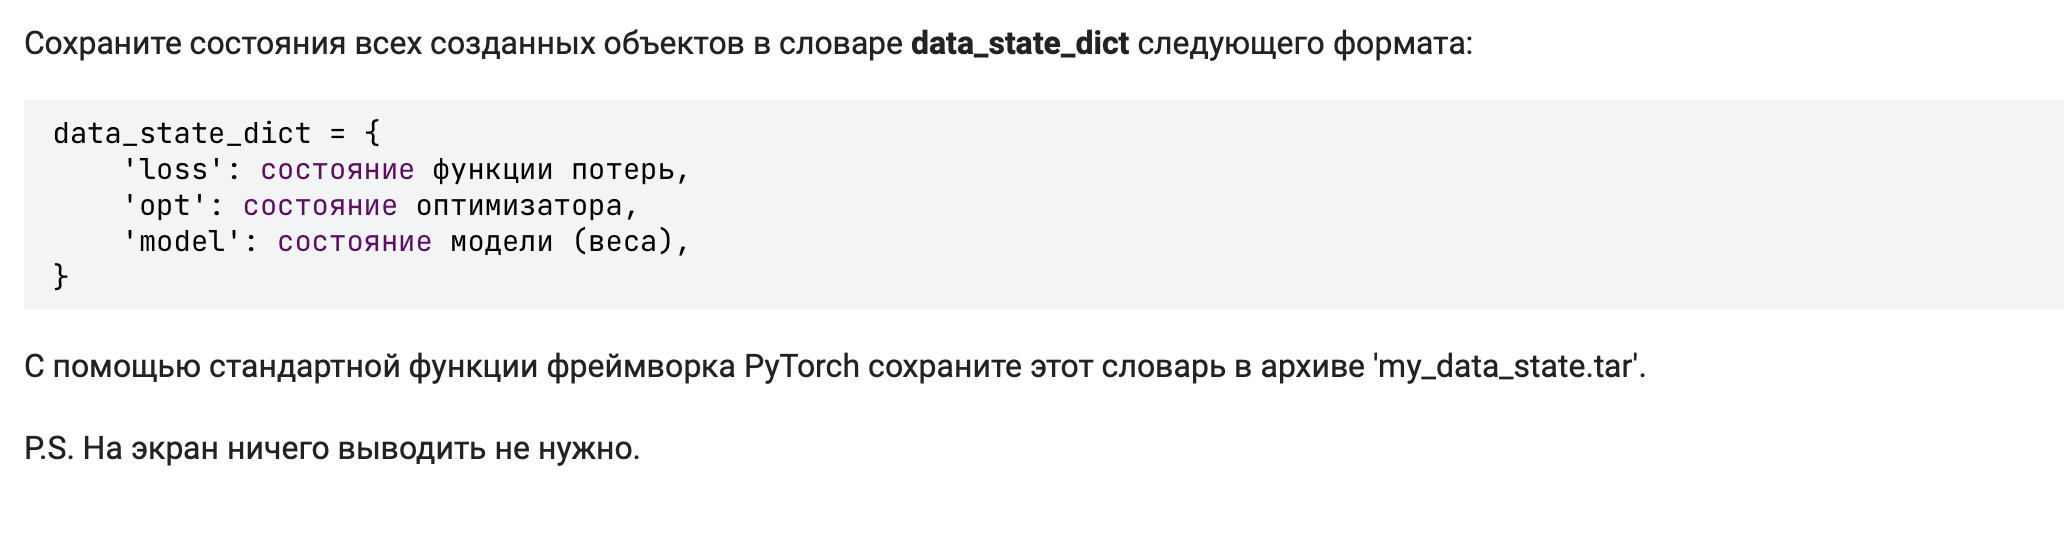

In [ ]:
# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out):
        super().__init__()
        self.layer1 = nn.Linear(inp, hid1, bias=False)
        self.layer2 = nn.Linear(hid1, hid2)
        self.out = nn.Linear(hid2, out, bias=False)

    def forward(self, x):
        x = self.layer1(x).tanh()
        x = self.layer2(x).tanh()
        x = self.out(x)

        return x
    
model = Model(25, 16, 8, 5)
opt = optim.Adam(model.parameters(), lr=0.02)
loss_func = nn.CrossEntropyLoss()

data_state_dict = {
    'loss': loss_func.state_dict(),
    'opt': opt.state_dict(),
    'model': model.state_dict()
}

torch.save(data_state_dict, "my_data_state.tar")

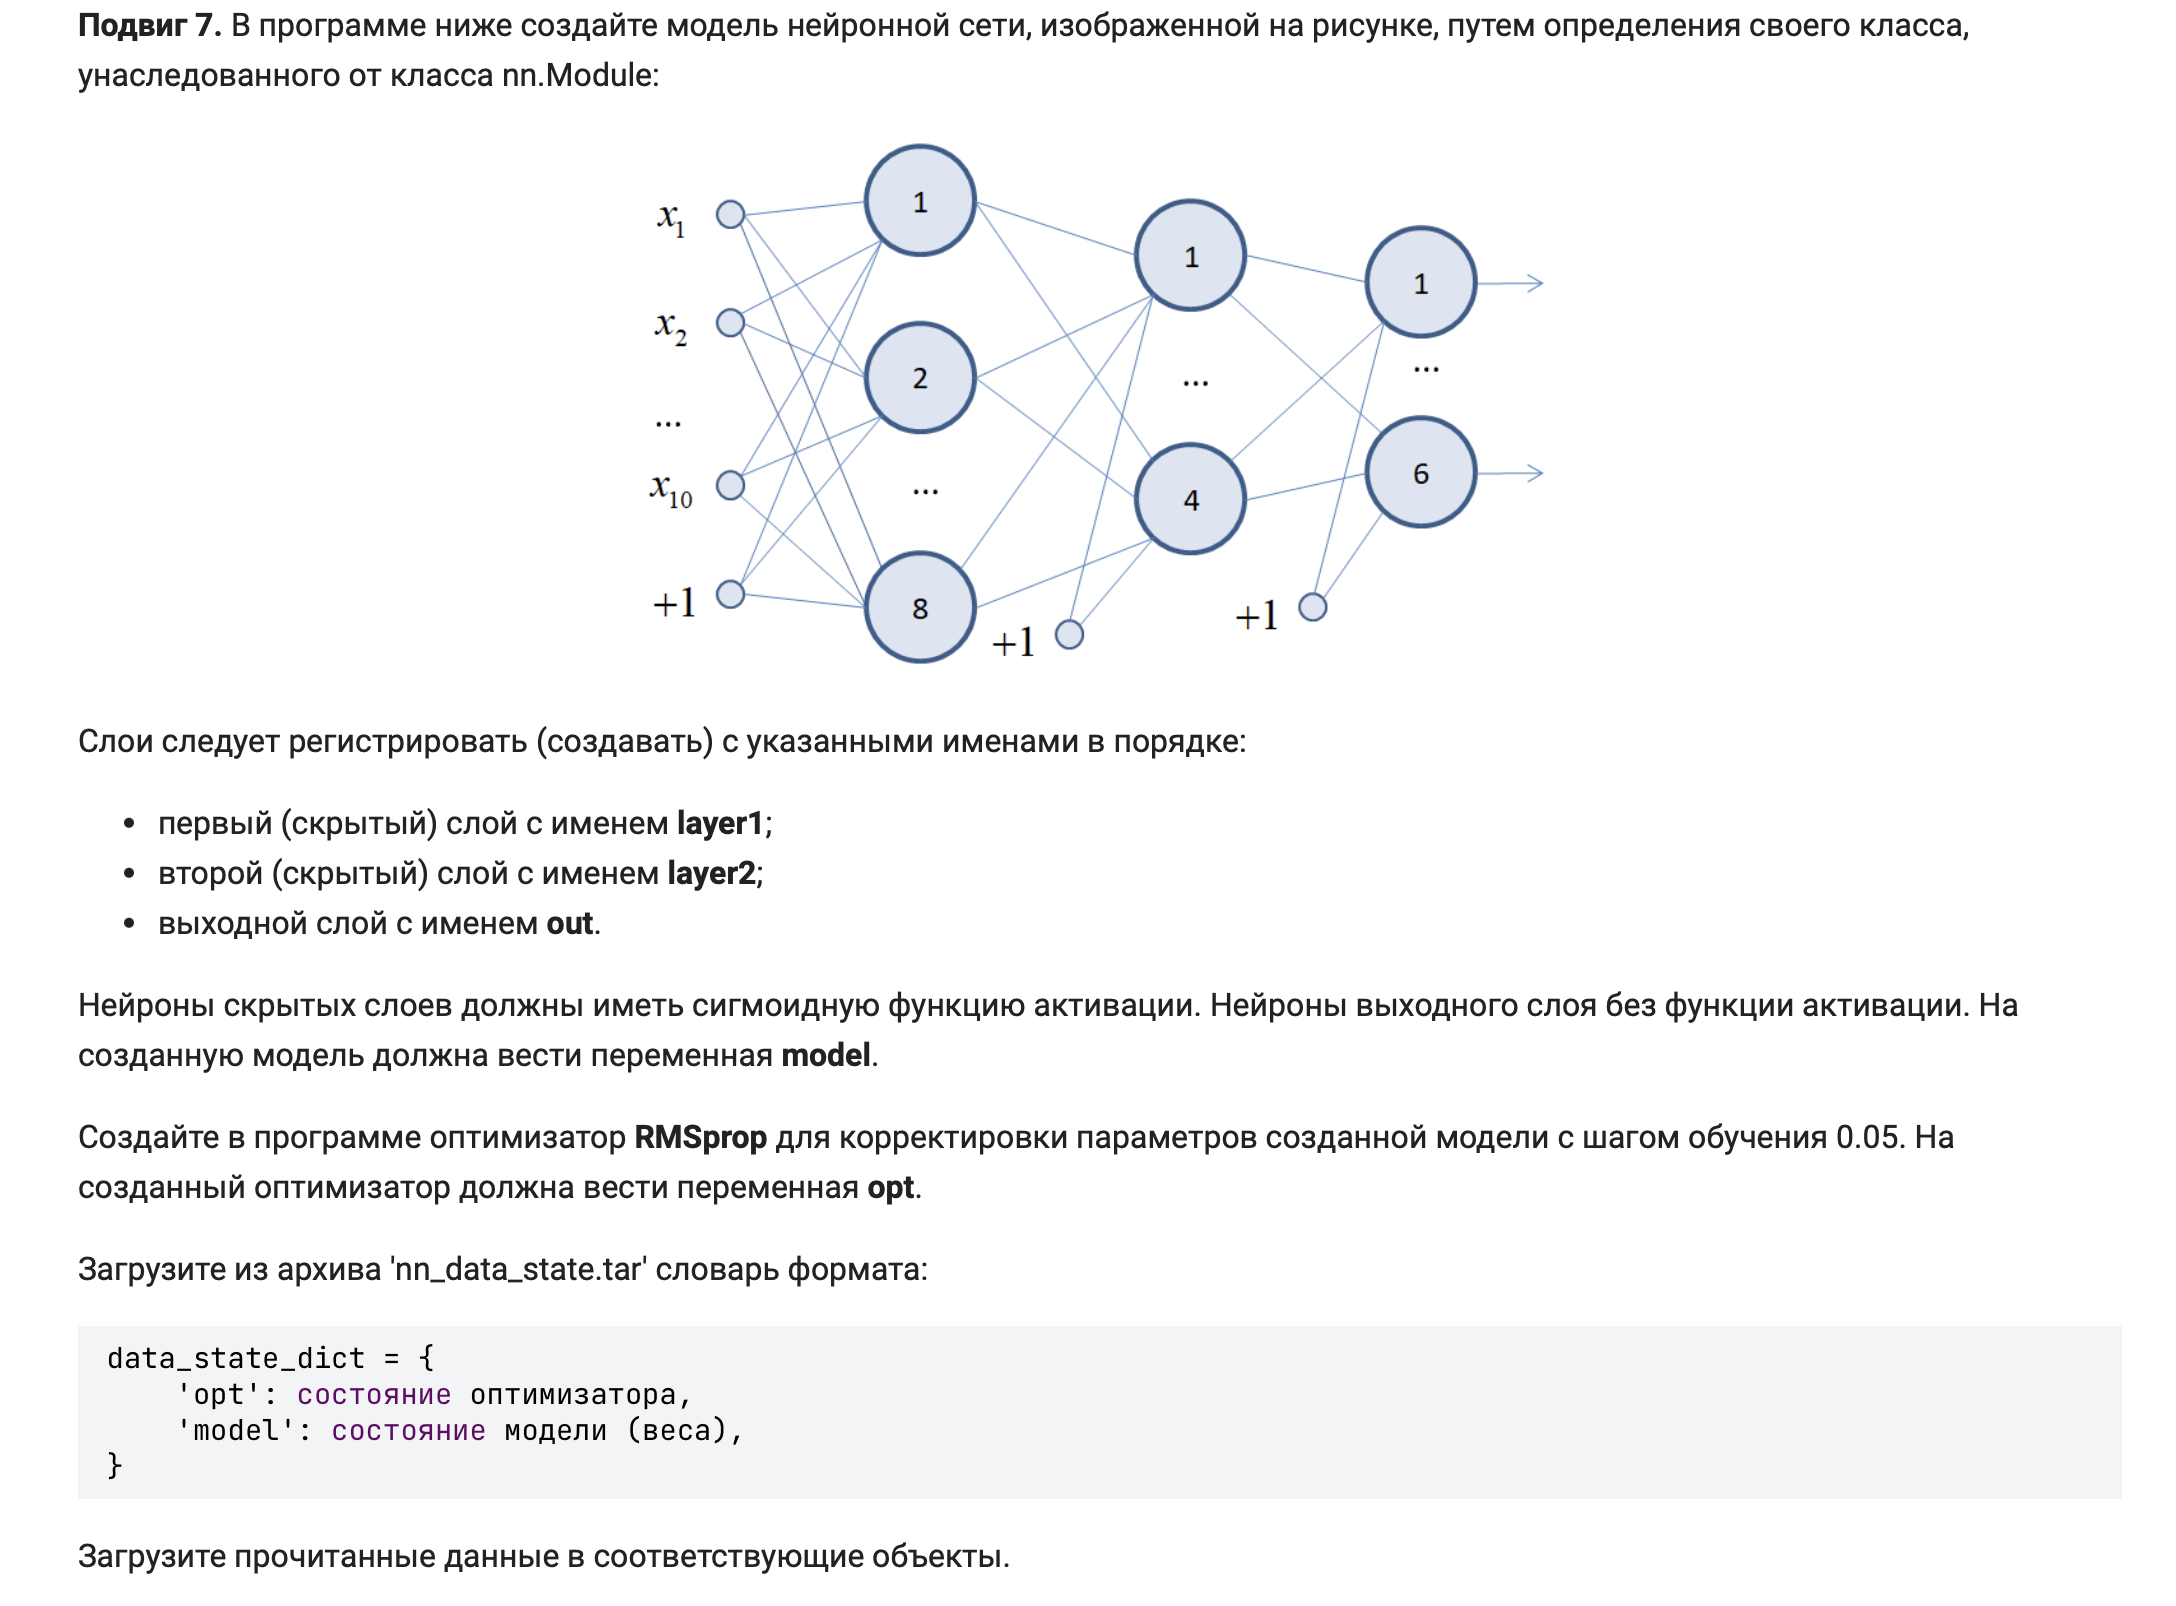

In [ ]:
# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out):
        super().__init__()
        self.layer1 = nn.Linear(inp, hid1, bias=True)
        self.layer2 = nn.Linear(hid1, hid2)
        self.out = nn.Linear(hid2, out, bias=True)

    def forward(self, x):
        x = self.layer1(x).sigmoid()
        x = self.layer2(x).sigmoid()
        x = self.out(x)

        return x
    
model = Model(10, 8, 4, 6)
opt = optim.RMSprop(model.parameters(), lr=0.05)

load_st = torch.load("nn_data_state.tar", weights_only=True)
model.load_state_dict(load_st['model'])
opt.load_state_dict(load_st['opt'])